In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2

from pathlib import Path
from tqdm import tqdm

# sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

# tensorflow
import tensorflow as tf
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy

# ── Output directories (fully isolated from previous runs) ──
os.makedirs("pipeline_v2/models",    exist_ok=True)
os.makedirs("pipeline_v2/artifacts", exist_ok=True)

print("TF version:", tf.__version__)
print("Directories ready: pipeline_v2/models/  |  pipeline_v2/artifacts/")

TF version: 2.13.0
Directories ready: pipeline_v2/models/  |  pipeline_v2/artifacts/


In [2]:
# ── Load fused feature matrix (EfficientNetB0 1280 + 32 handcrafted) ──
X  = np.load("artifacts/X.npy")
y  = np.load("artifacts/y.npy")                          # 0=fresh, 1=rotten
ft = np.load("artifacts/fruit_type.npy", allow_pickle=True)

FRUITS = sorted(np.unique(ft).tolist())

print(f"X shape   : {X.shape}")
print(f"y shape   : {y.shape}  | classes: {np.unique(y)} (0=fresh 1=rotten)")
print(f"Fruits    : {FRUITS}")
print(f"Fresh N   : {(y==0).sum()}  |  Rotten N: {(y==1).sum()}")

X shape   : (13232, 1310)
y shape   : (13232,)  | classes: [0 1] (0=fresh 1=rotten)
Fruits    : ['Apple', 'Banana', 'Capsicum', 'Cucumber', 'Potato']
Fresh N   : 6076  |  Rotten N: 7156


In [3]:
# ── Stratified 80/20 split ──
X_train, X_test, y_train, y_test, ft_train, ft_test = train_test_split(
    X, y, ft, test_size=0.2, stratify=y, random_state=42
)

# Persist split indices for reproducibility
np.save("pipeline_v2/artifacts/y_train.npy",  y_train)
np.save("pipeline_v2/artifacts/y_test.npy",   y_test)
np.save("pipeline_v2/artifacts/ft_train.npy", ft_train)
np.save("pipeline_v2/artifacts/ft_test.npy",  ft_test)

print("Train:", X_train.shape, "  Test:", X_test.shape)

Train: (10585, 1310)   Test: (2647, 1310)


---
## Stage 1 — Global Scaling

In [4]:
def fit_global_scaler(X_tr, X_te, save_path):
    """Fit StandardScaler on train, transform both splits."""
    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(X_tr)
    Xte_sc = sc.transform(X_te)
    joblib.dump(sc, save_path)
    return sc, Xtr_sc, Xte_sc

global_scaler, X_train_sc, X_test_sc = fit_global_scaler(
    X_train, X_test, "pipeline_v2/models/scaler.pkl"
)

print(f"Global scaler fitted. Mean≈0: {X_train_sc.mean():.4f}  Std≈1: {X_train_sc.std():.4f}")
print("Saved → pipeline_v2/models/scaler.pkl")

Global scaler fitted. Mean≈0: 0.0000  Std≈1: 1.0000
Saved → pipeline_v2/models/scaler.pkl


---
## Stage 2A — Fruit Feature Selection (RFE + LinearSVC)

Target: `fruit_type`  
Captures globally-discriminative morphological / colour signatures per fruit species.

In [5]:
def cv_rfe(X_tr, target, n_list, step, label, n_splits=5):
    """Stratified K-fold CV over RFE feature counts.
    Returns list of (n_features, mean_cv_accuracy).
    """
    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []
    for n in n_list:
        accs = []
        for tr_idx, val_idx in skf.split(X_tr, target):
            Xtr_cv, Xval_cv = X_tr[tr_idx], X_tr[val_idx]
            ytr_cv, yval_cv = target[tr_idx], target[val_idx]

            rfe_cv = RFE(
                estimator=LinearSVC(dual=False, max_iter=5000, C=0.1),
                n_features_to_select=n,
                step=step
            )
            Xs = rfe_cv.fit_transform(Xtr_cv, ytr_cv)
            Xv = rfe_cv.transform(Xval_cv)

            clf = SVC(kernel='rbf', C=1.0)
            clf.fit(Xs, ytr_cv)
            accs.append(accuracy_score(yval_cv, clf.predict(Xv)))

        mean_acc = np.mean(accs)
        results.append((n, mean_acc))
        print(f"  [{label}] n={n:>3d}  CV acc = {mean_acc:.4f}")
    return results

# ── Search over candidate counts ──
print("=" * 50)
print("Stage 2A: Fruit Feature CV")
print("=" * 50)
FRUIT_N_LIST = [80, 100, 120, 140]

fruit_cv_results = cv_rfe(
    X_train_sc, ft_train,
    n_list=FRUIT_N_LIST,
    step=100,
    label="FRUIT"
)

best_n_fruit = sorted(fruit_cv_results, key=lambda x: (-x[1], x[0]))[0][0]
print(f"\n>>> Best fruit feature count: {best_n_fruit}")

Stage 2A: Fruit Feature CV
  [FRUIT] n= 80  CV acc = 0.9898
  [FRUIT] n=100  CV acc = 0.9906
  [FRUIT] n=120  CV acc = 0.9914
  [FRUIT] n=140  CV acc = 0.9918

>>> Best fruit feature count: 140


In [6]:
# ── Final RFE on full training set ──
print("Fitting final RFE (fruit)...")
rfe_fruit = RFE(
    estimator=LinearSVC(dual=False, max_iter=5000, C=0.1),
    n_features_to_select=best_n_fruit,
    step=100
)
X_fruit_train_raw = rfe_fruit.fit_transform(X_train_sc, ft_train)
X_fruit_test_raw  = rfe_fruit.transform(X_test_sc)

# Stage-2 scaler for fruit feature sub-space
scaler_fruit = StandardScaler()
X_fruit_train = scaler_fruit.fit_transform(X_fruit_train_raw)
X_fruit_test  = scaler_fruit.transform(X_fruit_test_raw)

# Save
joblib.dump(rfe_fruit,    "pipeline_v2/models/rfe_fruit.pkl")
joblib.dump(scaler_fruit, "pipeline_v2/models/scaler_fruit.pkl")
np.save("pipeline_v2/artifacts/X_fruit_train.npy", X_fruit_train)
np.save("pipeline_v2/artifacts/X_fruit_test.npy",  X_fruit_test)

print(f"Fruit features shape: {X_fruit_train.shape}")
print("Saved → rfe_fruit.pkl  |  scaler_fruit.pkl")

Fitting final RFE (fruit)...
Fruit features shape: (10585, 140)
Saved → rfe_fruit.pkl  |  scaler_fruit.pkl


---
## Stage 2B — Freshness Feature Selection  
### MI-Guided Prefilter → RFE + LinearSVC

**Score formula:**  
$$\text{score}_i = MI(X_i,\, y) - 0.7 \cdot MI(X_i,\, \text{fruit\_type})$$

Retains features that are informative for freshness but **suppresses** those that merely encode fruit identity — enforcing separation of the two feature spaces.

In [7]:
print("=" * 50)
print("Stage 2B: Freshness MI-Guided Prefilter")
print("=" * 50)

# ── Mutual information ──
print("Computing MI(X, freshness)...")
mi_fresh = mutual_info_classif(X_train_sc, y_train,  random_state=42, n_neighbors=5)

print("Computing MI(X, fruit_type)...")
mi_fruit_vec = mutual_info_classif(X_train_sc, ft_train, random_state=42, n_neighbors=5)

# ── Composite freshness-discriminative score ──
fresh_score = mi_fresh - 0.7 * mi_fruit_vec

# ── Prefilter: keep top 300 ──
PREFILTER_K  = 300
top300_idx   = np.argsort(fresh_score)[-PREFILTER_K:]
X_pf_train   = X_train_sc[:, top300_idx]
X_pf_test    = X_test_sc[:,  top300_idx]

np.save("pipeline_v2/artifacts/top300_idx.npy", top300_idx)

print(f"After prefilter: {X_pf_train.shape}")
print(f"Mean fresh score (top-300): {fresh_score[top300_idx].mean():.4f}")

Stage 2B: Freshness MI-Guided Prefilter
Computing MI(X, freshness)...
Computing MI(X, fruit_type)...
After prefilter: (10585, 300)
Mean fresh score (top-300): -0.0090


In [8]:
# ── CV over freshness feature counts ──
print("=" * 50)
print("Stage 2B: Freshness RFE CV")
print("=" * 50)

FRESH_N_LIST = [80, 100, 120, 140]

fresh_cv_results = cv_rfe(
    X_pf_train, y_train,
    n_list=FRESH_N_LIST,
    step=50,
    label="FRESH"
)

best_n_fresh = sorted(fresh_cv_results, key=lambda x: (-x[1], x[0]))[0][0]
print(f"\n>>> Best freshness feature count: {best_n_fresh}")

Stage 2B: Freshness RFE CV
  [FRESH] n= 80  CV acc = 0.9695
  [FRESH] n=100  CV acc = 0.9726
  [FRESH] n=120  CV acc = 0.9735
  [FRESH] n=140  CV acc = 0.9765

>>> Best freshness feature count: 140


In [9]:
# ── Final RFE on full training set (freshness) ──
print("Fitting final RFE (freshness)...")
rfe_fresh = RFE(
    estimator=LinearSVC(dual=False, max_iter=5000, C=0.1),
    n_features_to_select=best_n_fresh,
    step=50
)
X_fresh_train_raw = rfe_fresh.fit_transform(X_pf_train, y_train)
X_fresh_test_raw  = rfe_fresh.transform(X_pf_test)

# Map selected indices back to original feature space
selected_in_pf   = np.where(rfe_fresh.support_)[0]
fresh_final_idx  = top300_idx[selected_in_pf]

# Stage-2 scaler for freshness sub-space
scaler_fresh = StandardScaler()
X_fresh_train = scaler_fresh.fit_transform(X_fresh_train_raw)
X_fresh_test  = scaler_fresh.transform(X_fresh_test_raw)

# Save
joblib.dump(rfe_fresh,    "pipeline_v2/models/rfe_fresh.pkl")
joblib.dump(scaler_fresh, "pipeline_v2/models/scaler_fresh.pkl")
np.save("pipeline_v2/artifacts/fresh_final_idx.npy",  fresh_final_idx)
np.save("pipeline_v2/artifacts/X_fresh_train.npy",    X_fresh_train)
np.save("pipeline_v2/artifacts/X_fresh_test.npy",     X_fresh_test)

print(f"Freshness features shape: {X_fresh_train.shape}")
print(f"Unique fresh indices (overlap check): {len(np.intersect1d(np.where(rfe_fruit.support_)[0], fresh_final_idx))} overlap with fruit features")
print("Saved → rfe_fresh.pkl  |  scaler_fresh.pkl")

Fitting final RFE (freshness)...
Freshness features shape: (10585, 140)
Unique fresh indices (overlap check): 18 overlap with fruit features
Saved → rfe_fresh.pkl  |  scaler_fresh.pkl


---
## Stage 3A — Fruit Classifier (SVC RBF)

Operates **only** on `X_fruit` — the fruit feature space.

In [10]:
def train_fruit_classifier(X_tr, ft_tr, X_te, ft_te):
    """Train RBF-SVC on fruit features and evaluate."""
    clf = SVC(kernel='rbf', C=10.0, probability=False)
    clf.fit(X_tr, ft_tr)

    pred = clf.predict(X_te)
    acc  = accuracy_score(ft_te, pred)
    print(f"Fruit classification accuracy: {acc:.4f}")
    print()
    print(classification_report(ft_te, pred))
    return clf, pred

print("=" * 50)
print("Stage 3A: Fruit Classifier")
print("=" * 50)

svm_fruit, fruit_pred = train_fruit_classifier(
    X_fruit_train, ft_train,
    X_fruit_test,  ft_test
)

joblib.dump(svm_fruit, "pipeline_v2/models/svm_fruit.pkl")
print("Saved → svm_fruit.pkl")

Stage 3A: Fruit Classifier
Fruit classification accuracy: 0.9943

              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       832
      Banana       0.99      1.00      1.00       975
    Capsicum       1.00      1.00      1.00       365
    Cucumber       0.98      0.96      0.97       190
      Potato       0.99      0.98      0.99       285

    accuracy                           0.99      2647
   macro avg       0.99      0.99      0.99      2647
weighted avg       0.99      0.99      0.99      2647

Saved → svm_fruit.pkl


---
## Stage 3B — DASFS: Dual-Anchor Spectral Freshness Scoring  
*(per-fruit, using freshness feature space only)*

For each fruit $f$:
1. Compute $\mu_{\text{fresh}}^f$, $\mu_{\text{rotten}}^f$ in $\mathcal{X}_{\text{fresh}}$  
2. Degradation axis: $\hat{a} = \frac{\mu_{\text{rotten}} - \mu_{\text{fresh}}}{\|\mu_{\text{rotten}} - \mu_{\text{fresh}}\|}$  
3. Anchor projections $p_{\text{fresh}} = \text{median}(X_{\text{fresh}}^f \cdot \hat{a})$, same for rotten  
4. $\text{spread} = \max(\sigma_{\text{fresh}}, \sigma_{\text{rotten}})$

In [11]:
def build_dasfs(X_fresh_tr, y_tr, ft_tr, fruits):
    """Build per-fruit DASFS anchors from freshness feature space."""
    dasfs_dict = {}

    for fruit in fruits:
        idx_f = (ft_tr == fruit) & (y_tr == 0)   # fresh
        idx_r = (ft_tr == fruit) & (y_tr == 1)   # rotten

        if idx_f.sum() < 5 or idx_r.sum() < 5:
            print(f"  [SKIP] {fruit}: insufficient samples")
            continue

        Xf = X_fresh_tr[idx_f]
        Xr = X_fresh_tr[idx_r]

        mu_f = Xf.mean(axis=0)
        mu_r = Xr.mean(axis=0)

        # Unit degradation axis
        axis      = mu_r - mu_f
        axis_norm = axis / (np.linalg.norm(axis) + 1e-8)

        # Projections
        proj_f = Xf @ axis_norm
        proj_r = Xr @ axis_norm

        p_fresh  = float(np.median(proj_f))
        p_rotten = float(np.median(proj_r))
        spread   = float(max(np.std(proj_f), np.std(proj_r)))

        dasfs_dict[fruit] = {
            "axis"    : axis_norm,
            "p_fresh" : p_fresh,
            "p_rotten": p_rotten,
            "spread"  : spread,
        }

        sep = (p_rotten - p_fresh) / (spread + 1e-8)
        print(f"  {fruit:12s}  p_fresh={p_fresh:7.3f}  p_rotten={p_rotten:7.3f}  "
              f"spread={spread:.3f}  sep={sep:.2f}")

    return dasfs_dict


def dasfs_predict(x_fresh_vec, fruit, dasfs_dict):
    """Score a single sample in [0,1] (1=very fresh, 0=rotten) with confidence.

    Parameters
    ----------
    x_fresh_vec : 1-D array, shape (n_fresh_features,)
    fruit       : predicted fruit label
    dasfs_dict  : fitted DASFS anchors

    Returns
    -------
    score      : float in [0, 1]
    confidence : float in [0, 1]  (1 = far from decision boundary)
    """
    d        = dasfs_dict[fruit]
    proj     = float(x_fresh_vec @ d["axis"])
    p_f      = d["p_fresh"]
    p_r      = d["p_rotten"]
    spread   = d["spread"]

    score    = float(np.clip((p_r - proj) / (p_r - p_f + 1e-8), 0.0, 1.0))

    mid      = (p_f + p_r) / 2.0
    u        = float(np.exp(-((proj - mid) ** 2) / (2.0 * spread ** 2 + 1e-8)))
    confidence = float(np.clip(1.0 - u, 0.0, 1.0))

    return score, confidence


print("=" * 50)
print("Stage 3B: DASFS Anchors")
print("=" * 50)

dasfs_dict = build_dasfs(X_fresh_train, y_train, ft_train, FRUITS)

joblib.dump(dasfs_dict, "pipeline_v2/models/dasfs.pkl")
print("\nSaved → dasfs.pkl")

Stage 3B: DASFS Anchors
  Apple         p_fresh= -2.974  p_rotten=  2.946  spread=2.449  sep=2.42
  Banana        p_fresh= -3.398  p_rotten=  2.854  spread=1.996  sep=3.13
  Capsicum      p_fresh= -2.855  p_rotten=  3.355  spread=2.247  sep=2.76
  Cucumber      p_fresh= -4.571  p_rotten=  1.367  spread=2.404  sep=2.47
  Potato        p_fresh= -2.615  p_rotten=  2.293  spread=2.761  sep=1.78

Saved → dasfs.pkl


In [12]:
# ── Evaluate DASFS on test set ──
scores_list = []
for i in range(len(X_fresh_test)):
    f = ft_test[i]
    if f not in dasfs_dict:
        continue
    s, c = dasfs_predict(X_fresh_test[i], f, dasfs_dict)
    scores_list.append((s, c, int(y_test[i])))

scores_arr  = np.array(scores_list)
pred_binary = (scores_arr[:, 0] > 0.5).astype(int)   # score>0.5 → fresh
true_binary = (scores_arr[:, 2] == 0).astype(int)

print("DASFS Test Accuracy:", accuracy_score(true_binary, pred_binary))
print(classification_report(true_binary, pred_binary, target_names=["Rotten", "Fresh"]))

DASFS Test Accuracy: 0.9176426142803173
              precision    recall  f1-score   support

      Rotten       0.94      0.90      0.92      1432
       Fresh       0.89      0.93      0.91      1215

    accuracy                           0.92      2647
   macro avg       0.92      0.92      0.92      2647
weighted avg       0.92      0.92      0.92      2647



---
## Stage 3C — KNN Anomaly Model (per fruit)

Trained **only on fresh samples** in the freshness feature space.  
High KNN distance → anomalous (rotten) signal.

In [13]:
def build_knn_dict(X_fresh_tr, y_tr, ft_tr, fruits, n_neighbors=5):
    """Fit one KNN model per fruit using FRESH samples only."""
    knn_dict = {}
    tau_dict = {}   # per-fruit bandwidth τ for distance→support conversion

    for fruit in fruits:
        idx_f = (ft_tr == fruit) & (y_tr == 0)
        if idx_f.sum() < n_neighbors + 1:
            print(f"  [SKIP] {fruit}: only {idx_f.sum()} fresh samples")
            continue

        Xf     = X_fresh_tr[idx_f]
        knn    = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
        knn.fit(Xf)

        # τ = median leave-one-out distance on fresh train (calibrated bandwidth)
        dists, _ = knn.kneighbors(Xf)
        tau      = float(np.median(dists.mean(axis=1)))

        knn_dict[fruit] = knn
        tau_dict[fruit] = tau if tau > 1e-6 else 1.0

        print(f"  {fruit:12s}  fresh_N={idx_f.sum()}  τ={tau:.4f}")

    return knn_dict, tau_dict


def knn_support(x_fresh_vec, fruit, knn_dict, tau_dict):
    """Convert KNN mean distance to freshness support score ∈ [0,1]."""
    k_dist  = float(knn_dict[fruit].kneighbors(x_fresh_vec.reshape(1, -1))[0].mean())
    tau     = tau_dict[fruit]
    support = float(np.exp(-k_dist / tau))
    return support, k_dist


print("=" * 50)
print("Stage 3C: Per-Fruit KNN")
print("=" * 50)

knn_dict, tau_dict = build_knn_dict(X_fresh_train, y_train, ft_train, FRUITS)

joblib.dump({"knn_dict": knn_dict, "tau_dict": tau_dict},
            "pipeline_v2/models/knn_dict.pkl")
print("\nSaved → knn_dict.pkl")

Stage 3C: Per-Fruit KNN
  Apple         fresh_N=1595  τ=4.2217
  Banana        fresh_N=1665  τ=5.1398
  Capsicum      fresh_N=745  τ=3.8668
  Cucumber      fresh_N=338  τ=6.1605
  Potato        fresh_N=518  τ=6.7603

Saved → knn_dict.pkl


---
## Stage 4 — Feature Extraction Utilities

Required at inference to reproduce the same 1280 + 32 = 1312 feature vector.

In [14]:
# ── Load EfficientNetB0 backbone (inference only) ──
efficientnet = tf.keras.applications.EfficientNetB0(
    include_top=False, weights='imagenet', pooling='avg'
)
preprocess_input = tf.keras.applications.efficientnet.preprocess_input
print("EfficientNetB0 loaded (1280-d output)")

EfficientNetB0 loaded (1280-d output)


In [26]:
def extract_handcrafted(img):
    """Extract 32 handcrafted features from a BGR image.
    Breakdown: RGB(6) + HSV(6) + LAB(6) + Texture(5) + Shape(6) + Dark(1) + Saturation(1) + Hue_std(1) = 32
    """
    img = cv2.resize(img, (224, 224)).astype(np.float32)

    # ── RGB (6) ──
    b, g, r = cv2.split(img)
    rgb = [r.mean(), g.mean(), b.mean(), r.std(), g.std(), b.std()]

    # ── HSV (6) ──
    hsv       = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2HSV)
    h, s, v   = (hsv[:, :, i].astype(np.float32) for i in range(3))
    h_rad     = h * (2 * np.pi / 180)
    cx, sx    = np.cos(h_rad).mean(), np.sin(h_rad).mean()
    h_mean    = float(np.arctan2(sx, cx))
    h_std     = float(np.sqrt(-2 * np.log(np.sqrt(cx**2 + sx**2) + 1e-6)))
    hsv_feat  = [h_mean, float(s.mean()), float(v.mean()), h_std, float(s.std()), float(v.std())]

    # ── LAB (6) ──
    lab       = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2LAB)
    L, a, b2  = (lab[:, :, i].astype(np.float32) for i in range(3))
    lab_feat  = [L.mean(), L.std(), a.mean(), a.std(), b2.mean(), b2.std()]

    # ── Texture (5) ──
    gray    = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY)
    lap     = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    g_      = (gray // 8).astype(np.uint8)
    glcm    = graycomatrix(g_, [1], [0], levels=32, symmetric=True, normed=True)
    contrast    = float(graycoprops(glcm, 'contrast')[0, 0])
    energy      = float(graycoprops(glcm, 'energy')[0, 0])
    homogeneity = float(graycoprops(glcm, 'homogeneity')[0, 0])
    hist, _     = np.histogram(gray, bins=256, range=(0, 255), density=True)
    ent         = float(entropy(hist + 1e-6))
    texture     = [lap, contrast, energy, homogeneity, ent]

    # ── Shape (6) ──
    _, th      = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _= cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c       = max(contours, key=cv2.contourArea)
        area    = float(cv2.contourArea(c))
        peri    = float(cv2.arcLength(c, True))
        circ    = float(4 * np.pi * area / (peri * peri + 1e-6))
        hull    = cv2.convexHull(c)
        hull_a  = float(cv2.contourArea(hull))
        solid   = float(area / (hull_a + 1e-6))
        x_, y_, w_, h_ = cv2.boundingRect(c)
        aspect  = float(w_ / (h_ + 1e-6))
        extent  = float(area / (w_ * h_ + 1e-6))
    else:
        area = peri = circ = solid = aspect = extent = 0.0
    shape = [area, peri, circ, solid, aspect, extent]

    # ── Dark pixel ratio (1) ──
    dark_ratio = float((gray < 50).mean())

    feats = rgb + hsv_feat + lab_feat + texture + shape + [dark_ratio]
    assert len(feats) == 30, f"Expected 32 handcrafted features, got {len(feats)}"
    return np.array(feats, dtype=np.float32)


def extract_features_single(img_bgr):
    """Extract full 1312-d feature vector from one BGR image."""
    img_rgb     = cv2.resize(img_bgr, (224, 224))
    x           = preprocess_input(np.expand_dims(img_rgb.astype(np.float32), 0))
    emb         = efficientnet.predict(x, verbose=0).flatten()     # (1280,)
    hand        = extract_handcrafted(img_bgr)                     # (32,)
    return np.concatenate([emb, hand])                             # (1312,)


print("Feature extractors defined. handcrafted=30  EfficientNet=1280  total=1310")

Feature extractors defined. handcrafted=30  EfficientNet=1280  total=1310


---
## Stage 4 — Inference Pipeline

Full `predict(image_path)` function with **strict feature-space separation**.

```
image → features(1312)
             ├─► [scaler] → [rfe_fruit] → [scaler_fruit] → x_fruit
             │                                                  └─► svm_fruit → fruit_label
             └─► [scaler] → top300 → [rfe_fresh] → [scaler_fresh] → x_fresh
                                                                         ├─► DASFS score + confidence
                                                                         └─► KNN support
```

In [27]:
def predict(image_path):
    """End-to-end freshness prediction for a single image.

    Parameters
    ----------
    image_path : str — path to image file

    Returns
    -------
    dict with keys:
        fruit           : predicted fruit type
        label           : freshness category
        freshness_score : float in [0, 100]
        dasfs_score     : DASFS component score (0–100)
        knn_support     : KNN component score  (0–100)
        confidence      : overall confidence   (0–100)
    """

    # ── Step 1: Load image ──
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    # ── Step 2: Feature extraction (1312) ──
    raw_feat = extract_features_single(img).reshape(1, -1)

    if raw_feat.shape[1] != global_scaler.mean_.shape[0]:
        raise ValueError(
            f"Feature dim mismatch: got {raw_feat.shape[1]}, "
            f"expected {global_scaler.mean_.shape[0]}"
        )

    # ── Step 3: Transform — fruit pipeline ──
    x_sc      = global_scaler.transform(raw_feat)                    # (1, 1312)
    x_fruit   = rfe_fruit.transform(x_sc)                           # (1, n_fruit)
    x_fruit   = scaler_fruit.transform(x_fruit)                     # (1, n_fruit) scaled

    # ── Step 4: Transform — freshness pipeline ──
    x_pf      = x_sc[:, top300_idx]                                 # (1, 300)
    x_fresh   = rfe_fresh.transform(x_pf)                           # (1, n_fresh)
    x_fresh   = scaler_fresh.transform(x_fresh)                     # (1, n_fresh) scaled

    # ── Step 5: Fruit prediction ──
    fruit = str(svm_fruit.predict(x_fruit)[0])

    # ── Fallback: unknown fruit ──
    if fruit not in dasfs_dict or fruit not in knn_dict:
        return {
            "fruit"          : fruit,
            "label"          : "Unknown",
            "freshness_score": -1.0,
            "dasfs_score"    : -1.0,
            "knn_support"    : -1.0,
            "confidence"     : 0.0,
        }

    xf_vec = x_fresh[0]   # 1-D freshness vector

    # ── Step 6: DASFS scoring ──
    #   score ∈ [0,1]: 1 = very fresh, 0 = rotten
    #   confidence ∈ [0,1]: 1 = far from decision boundary
    dasfs_score, dasfs_conf = dasfs_predict(xf_vec, fruit, dasfs_dict)

    # ── Step 7: KNN support ──
    knn_sup, k_dist = knn_support(xf_vec, fruit, knn_dict, tau_dict)

    # ── Step 8: Final score fusion ──
    final_score = dasfs_score                                       # primary signal
    final_conf  = 0.6 * dasfs_conf + 0.4 * knn_sup                 # as per spec

    freshness   = round(float(final_score) * 100.0, 2)

    # ── Step 9: Label ──
    if   freshness > 75: label = "Very Fresh"
    elif freshness > 50: label = "Fresh"
    elif freshness > 25: label = "Slightly Degraded"
    else:                label = "Rotten"

    return {
        "fruit"          : fruit,
        "label"          : label,
        "freshness_score": freshness,
        "dasfs_score"    : round(dasfs_score * 100, 2),
        "knn_support"    : round(knn_sup * 100, 2),
        "confidence"     : round(final_conf * 100, 1),
    }


print("predict() defined.")
print("Call: predict('path/to/image.jpg')")
print("Returns: fruit | label | freshness_score | dasfs_score | knn_support | confidence")

predict() defined.
Call: predict('path/to/image.jpg')
Returns: fruit | label | freshness_score | dasfs_score | knn_support | confidence


---
## Stage 5 — Diagnostic Plots

1. Accuracy vs feature count (fruit & fresh)
2. PCA cluster check (visual only — not used in model)
3. Mahalanobis distribution (diagnostic only — not in final model)
4. KNN distance distribution
5. DASFS projections per fruit

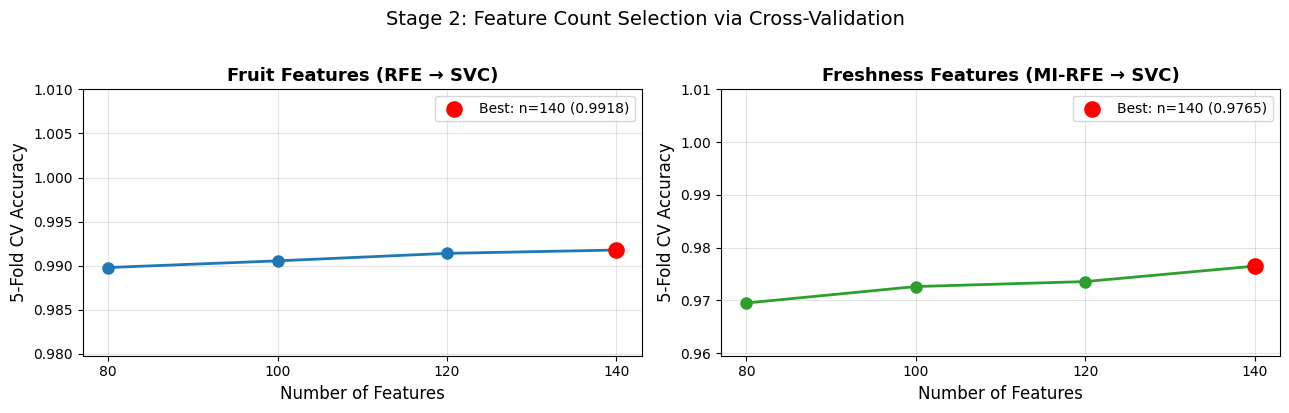

Saved → plot_accuracy_vs_features.png


In [17]:
# ── Plot 1: Accuracy vs Feature Count ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, results, title, color in zip(
    axes,
    [fruit_cv_results, fresh_cv_results],
    ["Fruit Features (RFE → SVC)", "Freshness Features (MI-RFE → SVC)"],
    ["#1f77b4", "#2ca02c"]
):
    ns   = [r[0] for r in results]
    accs = [r[1] for r in results]
    best_idx = int(np.argmax(accs))

    ax.plot(ns, accs, marker='o', color=color, linewidth=2, markersize=8)
    ax.scatter([ns[best_idx]], [accs[best_idx]], color='red', zorder=5,
               s=120, label=f"Best: n={ns[best_idx]} ({accs[best_idx]:.4f})")
    ax.set_xlabel("Number of Features", fontsize=12)
    ax.set_ylabel("5-Fold CV Accuracy", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(ns)
    ax.set_ylim(min(accs) - 0.01, 1.01)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.35)

plt.suptitle("Stage 2: Feature Count Selection via Cross-Validation", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("pipeline_v2/artifacts/plot_accuracy_vs_features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plot_accuracy_vs_features.png")

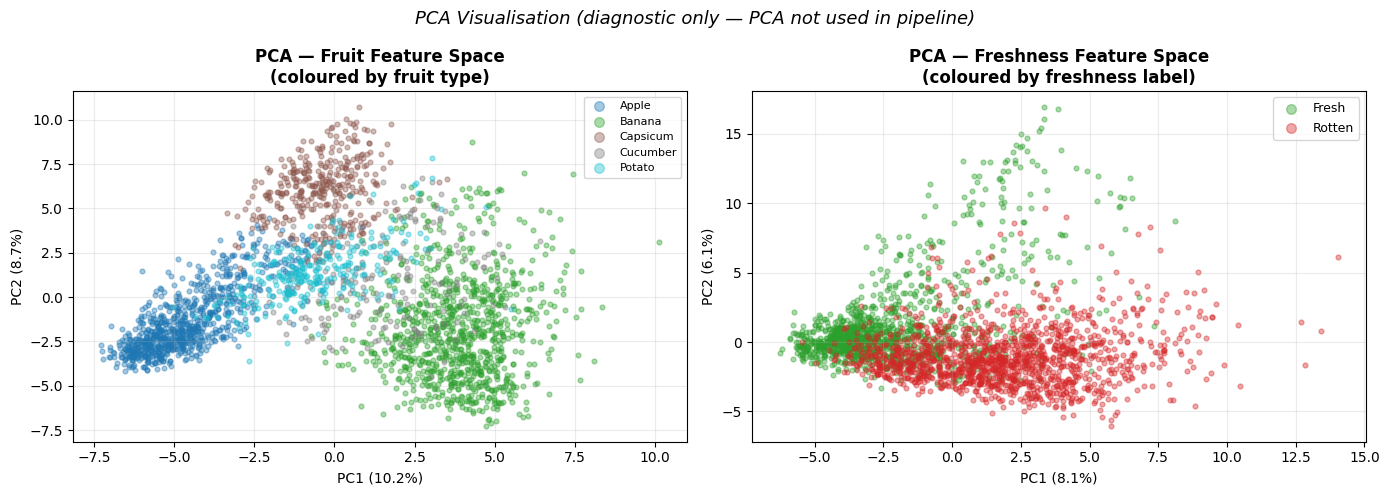

Saved → plot_pca.png


In [18]:
# ── Plot 2: PCA Cluster Visualisation (VISUAL ONLY — not used in model) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pca2 = PCA(n_components=2, random_state=42)

# Fruit space — coloured by fruit type
Xf_pca = pca2.fit_transform(X_fruit_test)
fruit_labels = np.unique(ft_test)
cmap_f = plt.cm.get_cmap('tab10', len(fruit_labels))
for i, fl in enumerate(fruit_labels):
    mask = ft_test == fl
    axes[0].scatter(Xf_pca[mask, 0], Xf_pca[mask, 1],
                    alpha=0.4, s=12, color=cmap_f(i), label=fl)
axes[0].set_title("PCA — Fruit Feature Space\n(coloured by fruit type)", fontweight='bold')
axes[0].legend(markerscale=2, fontsize=8)
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].grid(alpha=0.25)

# Fresh space — coloured by freshness
pca2b = PCA(n_components=2, random_state=42)
Xr_pca = pca2b.fit_transform(X_fresh_test)
for lbl, clr, nm in [(0, '#2ca02c', 'Fresh'), (1, '#d62728', 'Rotten')]:
    mask = y_test == lbl
    axes[1].scatter(Xr_pca[mask, 0], Xr_pca[mask, 1],
                    alpha=0.4, s=12, color=clr, label=nm)
axes[1].set_title("PCA — Freshness Feature Space\n(coloured by freshness label)", fontweight='bold')
axes[1].legend(markerscale=2, fontsize=9)
axes[1].set_xlabel(f"PC1 ({pca2b.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca2b.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].grid(alpha=0.25)

plt.suptitle("PCA Visualisation (diagnostic only — PCA not used in pipeline)",
             fontsize=13, style='italic')
plt.tight_layout()
plt.savefig("pipeline_v2/artifacts/plot_pca.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plot_pca.png")

Computing Mahalanobis distances (diagnostic)...


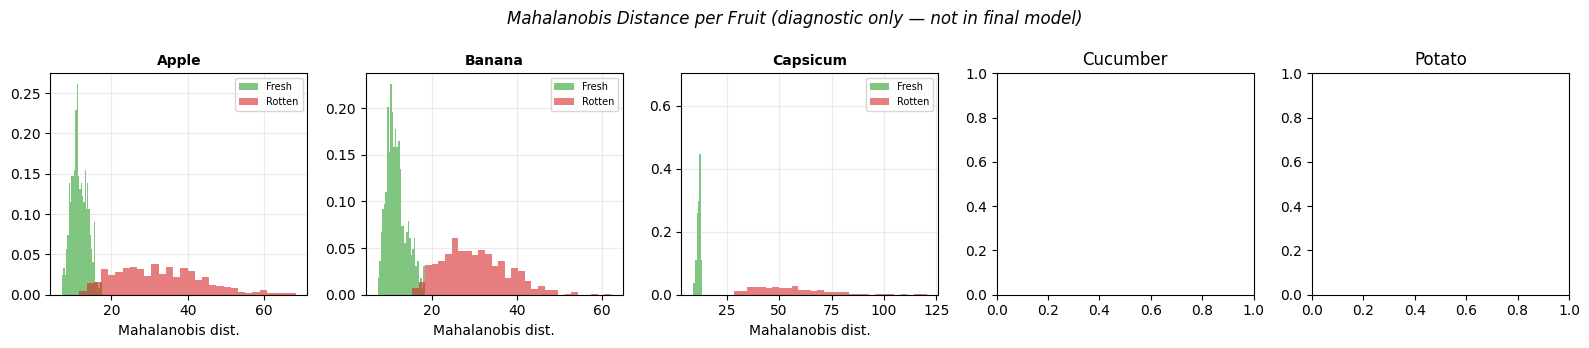

Saved → plot_mahalanobis.png


In [19]:
# ── Plot 3: Mahalanobis Distance (DIAGNOSTIC ONLY — not in final model) ──
def compute_mahalanobis_per_fruit(X_fr, y_fr, ft_fr, fruits):
    """Compute per-sample Mahalanobis distance from fruit-specific fresh centroid.
    Used for diagnostic visualisation only.
    """
    M = np.full(len(X_fr), np.nan)
    for fruit in fruits:
        idx_all   = ft_fr == fruit
        idx_fresh = idx_all & (y_fr == 0)
        if idx_fresh.sum() < X_fr.shape[1] + 2:
            continue
        Xf  = X_fr[idx_fresh]
        mu  = Xf.mean(axis=0)
        cov = np.cov(Xf, rowvar=False) + 1e-4 * np.eye(Xf.shape[1])
        inv = np.linalg.pinv(cov)
        diff = X_fr[idx_all] - mu
        M[idx_all] = np.sqrt(np.einsum('ij,jk,ik->i', diff, inv, diff))
    return M


print("Computing Mahalanobis distances (diagnostic)...")
M_test = compute_mahalanobis_per_fruit(X_fresh_test, y_test, ft_test, FRUITS)

fig, axes = plt.subplots(1, len(FRUITS), figsize=(16, 3.5), sharey=False)
for ax, fruit in zip(axes, FRUITS):
    mask = ft_test == fruit
    Mf   = M_test[mask]
    yf   = y_test[mask]
    valid = ~np.isnan(Mf)
    if valid.sum() == 0:
        ax.set_title(fruit); continue
    ax.hist(Mf[valid & (yf == 0)], bins=30, alpha=0.6, color='#2ca02c', label='Fresh', density=True)
    ax.hist(Mf[valid & (yf == 1)], bins=30, alpha=0.6, color='#d62728', label='Rotten', density=True)
    ax.set_title(fruit, fontsize=10, fontweight='bold')
    ax.set_xlabel("Mahalanobis dist.")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

plt.suptitle("Mahalanobis Distance per Fruit (diagnostic only — not in final model)",
             fontsize=12, style='italic')
plt.tight_layout()
plt.savefig("pipeline_v2/artifacts/plot_mahalanobis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plot_mahalanobis.png")

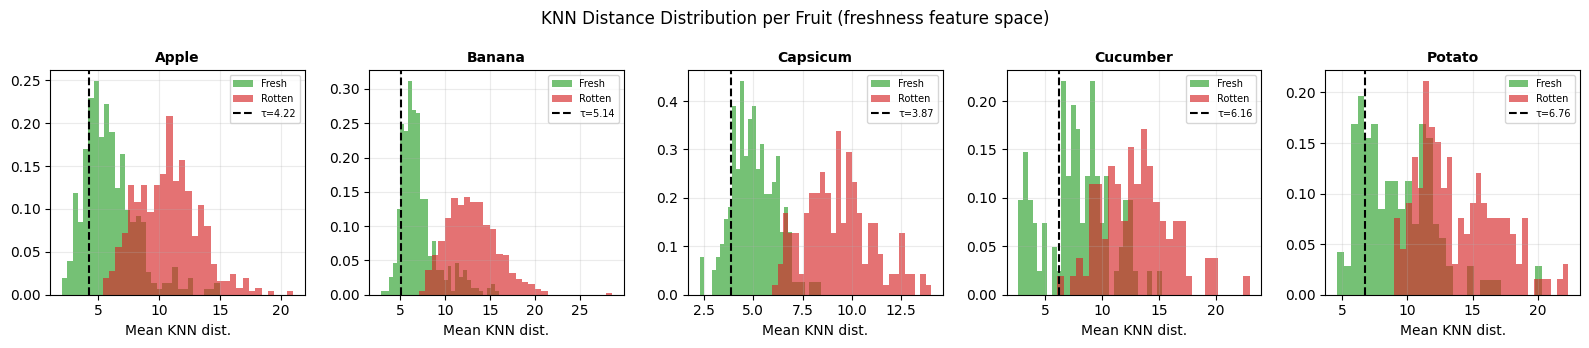

Saved → plot_knn_dist.png


In [20]:
# ── Plot 4: KNN Distance Distribution per Fruit ──
fig, axes = plt.subplots(1, len(FRUITS), figsize=(16, 3.5), sharey=False)

for ax, fruit in zip(axes, FRUITS):
    if fruit not in knn_dict:
        ax.set_title(fruit); continue

    mask  = ft_test == fruit
    Xfr   = X_fresh_test[mask]
    yfr   = y_test[mask]

    dists, _ = knn_dict[fruit].kneighbors(Xfr)
    kdist    = dists.mean(axis=1)

    ax.hist(kdist[yfr == 0], bins=30, alpha=0.65, color='#2ca02c', label='Fresh', density=True)
    ax.hist(kdist[yfr == 1], bins=30, alpha=0.65, color='#d62728', label='Rotten', density=True)
    ax.axvline(tau_dict[fruit], color='black', ls='--', lw=1.5, label=f'τ={tau_dict[fruit]:.2f}')
    ax.set_title(fruit, fontsize=10, fontweight='bold')
    ax.set_xlabel("Mean KNN dist.")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

plt.suptitle("KNN Distance Distribution per Fruit (freshness feature space)", fontsize=12)
plt.tight_layout()
plt.savefig("pipeline_v2/artifacts/plot_knn_dist.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plot_knn_dist.png")

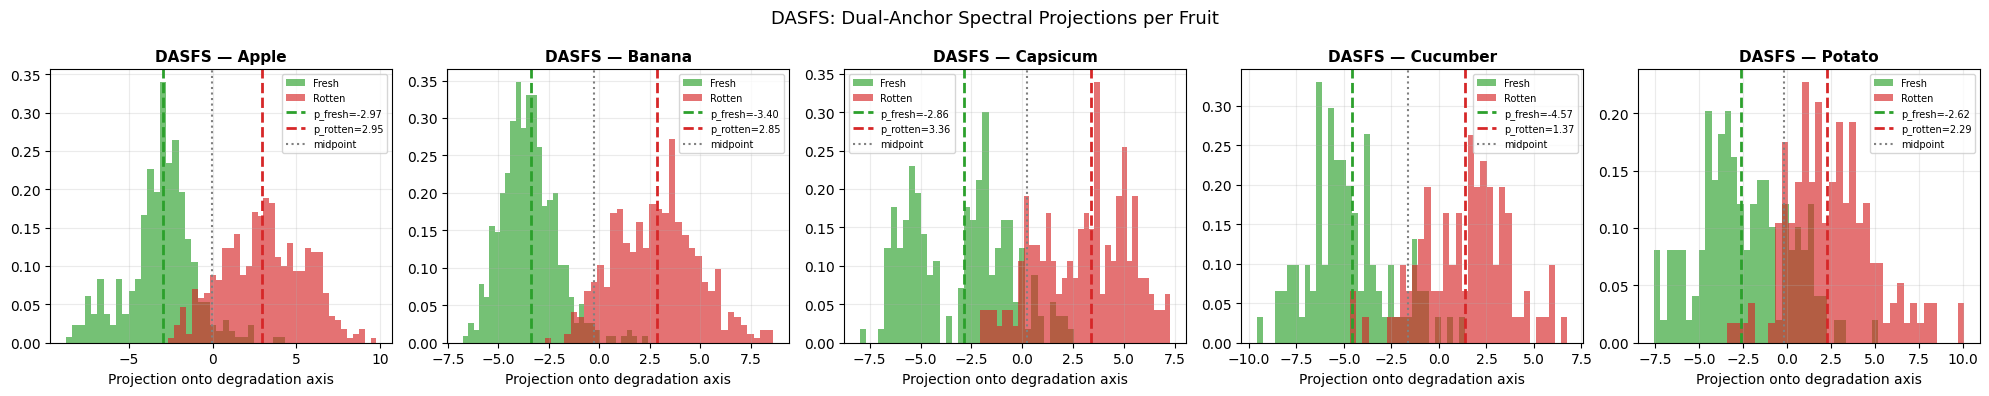

Saved → plot_dasfs_projections.png


In [21]:
# ── Plot 5: DASFS Projection per Fruit ──
n_fruits = len([f for f in FRUITS if f in dasfs_dict])
fig, axes = plt.subplots(1, n_fruits, figsize=(4 * n_fruits, 4), sharey=False)

if n_fruits == 1:
    axes = [axes]

ax_idx = 0
for fruit in FRUITS:
    if fruit not in dasfs_dict:
        continue
    ax   = axes[ax_idx]
    d    = dasfs_dict[fruit]
    mask = ft_test == fruit
    Xfr  = X_fresh_test[mask]
    yfr  = y_test[mask]

    proj = Xfr @ d["axis"]

    ax.hist(proj[yfr == 0], bins=35, alpha=0.65, color='#2ca02c', label='Fresh', density=True)
    ax.hist(proj[yfr == 1], bins=35, alpha=0.65, color='#d62728', label='Rotten', density=True)
    ax.axvline(d["p_fresh"],  color='#2ca02c', ls='--', lw=2, label=f'p_fresh={d["p_fresh"]:.2f}')
    ax.axvline(d["p_rotten"], color='#d62728', ls='--', lw=2, label=f'p_rotten={d["p_rotten"]:.2f}')
    ax.axvline((d["p_fresh"]+d["p_rotten"])/2, color='grey', ls=':', lw=1.5, label='midpoint')
    ax.set_title(f"DASFS — {fruit}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Projection onto degradation axis")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)
    ax_idx += 1

plt.suptitle("DASFS: Dual-Anchor Spectral Projections per Fruit", fontsize=13)
plt.tight_layout()
plt.savefig("pipeline_v2/artifacts/plot_dasfs_projections.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plot_dasfs_projections.png")

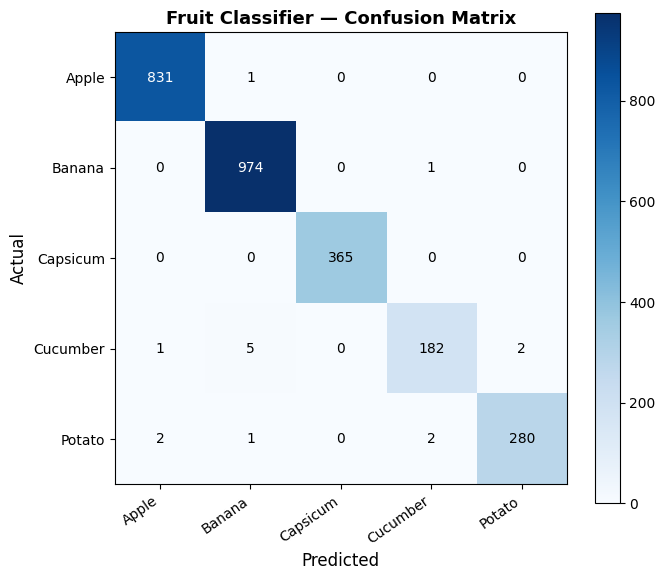

Saved → plot_confusion_fruit.png


In [22]:
# ── Plot 6: Fruit Classifier Confusion Matrix ──
cm_fruit = confusion_matrix(ft_test, svm_fruit.predict(X_fruit_test),
                             labels=FRUITS)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_fruit, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(FRUITS))); ax.set_xticklabels(FRUITS, rotation=35, ha='right')
ax.set_yticks(range(len(FRUITS))); ax.set_yticklabels(FRUITS)
ax.set_xlabel("Predicted", fontsize=12); ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Fruit Classifier — Confusion Matrix", fontsize=13, fontweight='bold')
for i in range(len(FRUITS)):
    for j in range(len(FRUITS)):
        ax.text(j, i, cm_fruit[i, j], ha='center', va='center',
                color='white' if cm_fruit[i, j] > cm_fruit.max() * 0.5 else 'black')
plt.tight_layout()
plt.savefig("pipeline_v2/artifacts/plot_confusion_fruit.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plot_confusion_fruit.png")

---
## Stage 6 — Save All Models

All artefacts written to `pipeline_v2/models/` — completely isolated from previous notebooks.

In [23]:
def save_all_models():
    """Persist entire pipeline to pipeline_v2/models/."""
    manifest = {
        "pipeline_v2/models/scaler.pkl"      : global_scaler,
        "pipeline_v2/models/scaler_fruit.pkl": scaler_fruit,
        "pipeline_v2/models/scaler_fresh.pkl": scaler_fresh,
        "pipeline_v2/models/rfe_fruit.pkl"   : rfe_fruit,
        "pipeline_v2/models/rfe_fresh.pkl"   : rfe_fresh,
        "pipeline_v2/models/svm_fruit.pkl"   : svm_fruit,
        "pipeline_v2/models/dasfs.pkl"       : dasfs_dict,
        "pipeline_v2/models/knn_dict.pkl"    : {"knn_dict": knn_dict, "tau_dict": tau_dict},
    }

    # Feature indices
    np.save("pipeline_v2/artifacts/top300_idx.npy",      top300_idx)
    np.save("pipeline_v2/artifacts/fresh_final_idx.npy", fresh_final_idx)

    print(f"{'FILE':<45}  {'SIZE':>10}")
    print("-" * 58)
    for path, obj in manifest.items():
        joblib.dump(obj, path)
        size = os.path.getsize(path)
        print(f"{path:<45}  {size/1024:>8.1f} KB")

    print("-" * 58)
    print("All models saved to pipeline_v2/models/")


save_all_models()

FILE                                                 SIZE
----------------------------------------------------------
pipeline_v2/models/scaler.pkl                      31.3 KB
pipeline_v2/models/scaler_fruit.pkl                 3.9 KB
pipeline_v2/models/scaler_fresh.pkl                 3.9 KB
pipeline_v2/models/rfe_fruit.pkl                   13.2 KB
pipeline_v2/models/rfe_fresh.pkl                    3.7 KB
pipeline_v2/models/svm_fruit.pkl                 2067.1 KB
pipeline_v2/models/dasfs.pkl                        3.4 KB
pipeline_v2/models/knn_dict.pkl                  2659.6 KB
----------------------------------------------------------
All models saved to pipeline_v2/models/


---
## Stage 6B — Load & Smoke Test

Demonstrates loading from disk and running inference from scratch — validates the full save/load cycle.

In [28]:
def load_pipeline(base="pipeline_v2"):
    """Load the full pipeline from disk. Returns a predict() callable."""
    m = f"{base}/models"
    a = f"{base}/artifacts"

    _global_scaler  = joblib.load(f"{m}/scaler.pkl")
    _scaler_fruit   = joblib.load(f"{m}/scaler_fruit.pkl")
    _scaler_fresh   = joblib.load(f"{m}/scaler_fresh.pkl")
    _rfe_fruit      = joblib.load(f"{m}/rfe_fruit.pkl")
    _rfe_fresh      = joblib.load(f"{m}/rfe_fresh.pkl")
    _svm_fruit      = joblib.load(f"{m}/svm_fruit.pkl")
    _dasfs          = joblib.load(f"{m}/dasfs.pkl")
    knn_bundle      = joblib.load(f"{m}/knn_dict.pkl")
    _knn_dict       = knn_bundle["knn_dict"]
    _tau_dict       = knn_bundle["tau_dict"]
    _top300_idx     = np.load(f"{a}/top300_idx.npy")

    def _predict(image_path):
        img = cv2.imread(str(image_path))
        if img is None:
            raise FileNotFoundError(image_path)

        raw_feat = extract_features_single(img).reshape(1, -1)
        x_sc     = _global_scaler.transform(raw_feat)

        # Fruit pipeline
        x_fruit  = _scaler_fruit.transform(_rfe_fruit.transform(x_sc))
        fruit    = str(_svm_fruit.predict(x_fruit)[0])

        if fruit not in _dasfs or fruit not in _knn_dict:
            return {"fruit": fruit, "label": "Unknown",
                    "freshness_score": -1.0, "confidence": 0.0}

        # Fresh pipeline
        x_fresh  = _scaler_fresh.transform(
                       _rfe_fresh.transform(x_sc[:, _top300_idx])
                   )
        xf_vec   = x_fresh[0]

        d_score, d_conf = dasfs_predict(xf_vec, fruit, _dasfs)
        k_sup, _        = knn_support(xf_vec, fruit, _knn_dict, _tau_dict)

        freshness = round(d_score * 100, 2)
        conf      = round((0.6 * d_conf + 0.4 * k_sup) * 100, 1)

        if   freshness > 75: lbl = "Very Fresh"
        elif freshness > 50: lbl = "Fresh"
        elif freshness > 25: lbl = "Slightly Degraded"
        else:                lbl = "Rotten"

        return {"fruit": fruit, "label": lbl,
                "freshness_score": freshness,
                "dasfs_score": round(d_score*100, 2),
                "knn_support":  round(k_sup*100, 2),
                "confidence":   conf}

    return _predict


# ── Smoke test on a few random test images (requires DataSet folder) ──
predict_loaded = load_pipeline()
print("Pipeline loaded from disk.")

exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

test_imgs = []
for cls in ["Fresh", "Rotten"]:
    base_p = Path(f"DataSet/{cls}")
    if base_p.exists():
        imgs = [str(p) for p in base_p.rglob("*") if p.suffix.lower() in exts][:2]
        test_imgs.extend(imgs)

if not test_imgs:
    print("No DataSet images found — skipping smoke test. Call predict('your_image.jpg') directly.")
else:
    print(f"{'IMAGE':<55} {'FRUIT':<12} {'LABEL':<20} {'SCORE':>6}  {'CONF':>6}")
    print("-" * 110)
    for p in test_imgs:
        try:
            r = predict_loaded(p)
            print(f"{os.path.basename(p):<55} {r['fruit']:<12} {r['label']:<20} "
                  f"{r['freshness_score']:>5.1f}%  {r['confidence']:>5.1f}%")
        except Exception as e:
            print(f"{p}: ERROR — {e}")

Pipeline loaded from disk.
IMAGE                                                   FRUIT        LABEL                 SCORE    CONF
--------------------------------------------------------------------------------------------------------------
a_f004.png                                              Apple        Very Fresh           100.0%   49.2%
a_f005.png                                              Apple        Very Fresh           100.0%   47.0%
000001.jpg                                              Apple        Rotten                 0.0%   40.4%
000002.jpg                                              Apple        Rotten                 0.0%   43.9%


# PREDICTION

[1/3] Loading models ... done
[2/3] Loading EfficientNetB0 ... done
[3/3] Running inference on: test_img/fresh_cucumber3.jpg


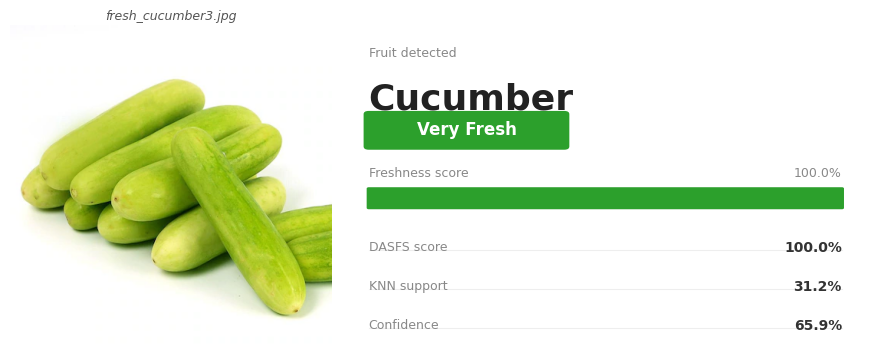


  Fruit   : Cucumber
  Grade   : Very Fresh
  Score   : 100.0%
  Conf    : 65.9%
  DASFS   : 100.0%   KNN: 31.2%


In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║         STANDALONE FRUIT FRESHNESS PREDICTOR                    ║
# ║  Run this cell alone — no other cells needed                    ║
# ║  Just set IMAGE_PATH below and run                              ║
# ╚══════════════════════════════════════════════════════════════════╝

IMAGE_PATH   = "test_img/fresh_cucumber3.jpg"   # ← change this
PIPELINE_DIR = "pipeline_v2"                           # ← change if renamed

# ─────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────
import os, sys, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import cv2
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
import tensorflow as tf

# ─────────────────────────────────────────────────────────────────
# FEATURE EXTRACTION  (1280 EfficientNet + 30 handcrafted = 1310)
# ─────────────────────────────────────────────────────────────────
def _extract_handcrafted(img):
    """30 features: RGB(6)+HSV(6)+LAB(6)+Texture(5)+Shape(6)+Dark(1)"""
    img = cv2.resize(img, (224, 224)).astype(np.float32)

    b, g, r = cv2.split(img)
    rgb = [r.mean(), g.mean(), b.mean(), r.std(), g.std(), b.std()]

    hsv     = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2HSV)
    h, s, v = (hsv[:,:,i].astype(np.float32) for i in range(3))
    h_rad   = h * (2 * np.pi / 180)
    cx, sx  = np.cos(h_rad).mean(), np.sin(h_rad).mean()
    hsv_f   = [float(np.arctan2(sx, cx)), float(s.mean()), float(v.mean()),
               float(np.sqrt(-2*np.log(np.sqrt(cx**2+sx**2)+1e-6))),
               float(s.std()), float(v.std())]

    lab      = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2LAB)
    L,a,b2   = (lab[:,:,i].astype(np.float32) for i in range(3))
    lab_f    = [L.mean(), L.std(), a.mean(), a.std(), b2.mean(), b2.std()]

    gray        = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY)
    lap         = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    glcm        = graycomatrix((gray//8).astype(np.uint8), [1], [0],
                               levels=32, symmetric=True, normed=True)
    hist, _     = np.histogram(gray, bins=256, range=(0,255), density=True)
    tex_f       = [lap,
                   float(graycoprops(glcm,'contrast')[0,0]),
                   float(graycoprops(glcm,'energy')[0,0]),
                   float(graycoprops(glcm,'homogeneity')[0,0]),
                   float(entropy(hist+1e-6))]

    _, th       = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    cnts, _     = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        c       = max(cnts, key=cv2.contourArea)
        area    = float(cv2.contourArea(c))
        peri    = float(cv2.arcLength(c, True))
        hull_a  = float(cv2.contourArea(cv2.convexHull(c)))
        x_,y_,w_,h_ = cv2.boundingRect(c)
        shp_f   = [area, peri,
                   4*np.pi*area/(peri*peri+1e-6),
                   area/(hull_a+1e-6),
                   w_/(h_+1e-6),
                   area/(w_*h_+1e-6)]
    else:
        shp_f = [0.0]*6

    feats = rgb + hsv_f + lab_f + tex_f + shp_f + [float((gray<50).mean())]
    assert len(feats) == 30, f"handcrafted count error: {len(feats)}"
    return np.array(feats, dtype=np.float32)


# ─────────────────────────────────────────────────────────────────
# LOAD MODELS  (once)
# ─────────────────────────────────────────────────────────────────
print("[1/3] Loading models ...", end=" ", flush=True)

m = f"{PIPELINE_DIR}/models"
a = f"{PIPELINE_DIR}/artifacts"

global_scaler = joblib.load(f"{m}/scaler.pkl")
scaler_fruit  = joblib.load(f"{m}/scaler_fruit.pkl")
scaler_fresh  = joblib.load(f"{m}/scaler_fresh.pkl")
rfe_fruit     = joblib.load(f"{m}/rfe_fruit.pkl")
rfe_fresh     = joblib.load(f"{m}/rfe_fresh.pkl")
svm_fruit     = joblib.load(f"{m}/svm_fruit.pkl")
dasfs         = joblib.load(f"{m}/dasfs.pkl")
knn_bundle    = joblib.load(f"{m}/knn_dict.pkl")
knn_dict      = knn_bundle["knn_dict"]
tau_dict      = knn_bundle["tau_dict"]
top300_idx    = np.load(f"{a}/top300_idx.npy")

print("done")
print("[2/3] Loading EfficientNetB0 ...", end=" ", flush=True)

backbone  = tf.keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", pooling="avg"
)
preprocess = tf.keras.applications.efficientnet.preprocess_input
print("done")

# ─────────────────────────────────────────────────────────────────
# PREDICT
# ─────────────────────────────────────────────────────────────────
print(f"[3/3] Running inference on: {IMAGE_PATH}", flush=True)

img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Cannot read image: {IMAGE_PATH}")

# extract features
emb      = backbone.predict(
               preprocess(np.expand_dims(
                   cv2.resize(img,(224,224)).astype(np.float32), 0)),
               verbose=0).flatten()
hand     = _extract_handcrafted(img)
raw_feat = np.concatenate([emb, hand]).reshape(1, -1)      # (1, 1310)

# scale
x_sc = global_scaler.transform(raw_feat)

# ── Fruit pipeline ──
x_fruit = scaler_fruit.transform(rfe_fruit.transform(x_sc))
fruit   = str(svm_fruit.predict(x_fruit)[0])

# ── Freshness pipeline ──
x_fresh  = scaler_fresh.transform(rfe_fresh.transform(x_sc[:, top300_idx]))
xf_vec   = x_fresh[0]

# DASFS
d        = dasfs[fruit]
proj     = float(xf_vec @ d["axis"])
p_f, p_r = d["p_fresh"], d["p_rotten"]
score    = float(np.clip((p_r - proj) / (p_r - p_f + 1e-8), 0.0, 1.0))
mid      = (p_f + p_r) / 2.0
dasfs_conf = float(np.clip(1.0 - np.exp(-((proj-mid)**2)/(2*d["spread"]**2+1e-8)), 0, 1))

# KNN
k_dist   = float(knn_dict[fruit].kneighbors(xf_vec.reshape(1,-1))[0].mean())
knn_sup  = float(np.exp(-k_dist / (tau_dict[fruit] + 1e-8)))

# Final
freshness = round(score * 100, 2)
conf      = round((0.6 * dasfs_conf + 0.4 * knn_sup) * 100, 1)

if   freshness > 75: label, lc = "Very Fresh",        "#2ca02c"
elif freshness > 50: label, lc = "Fresh",             "#74c476"
elif freshness > 25: label, lc = "Slightly Degraded", "#fd8d3c"
else:                label, lc = "Rotten",            "#d62728"

# ─────────────────────────────────────────────────────────────────
# DISPLAY
# ─────────────────────────────────────────────────────────────────
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig = plt.figure(figsize=(11, 4.2), facecolor="white")
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.6], wspace=0.04)

# ── Left: image ──
ax_img = fig.add_subplot(gs[0])
ax_img.imshow(img_rgb)
ax_img.axis("off")
ax_img.set_title(Path(IMAGE_PATH).name, fontsize=9,
                 color="#555", pad=4, style="italic")

# ── Right: results panel ──
ax = fig.add_subplot(gs[1])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Fruit chip
ax.text(0.04, 0.93, "Fruit detected",
        fontsize=9, color="#888", va="top")
ax.text(0.04, 0.82, fruit,
        fontsize=26, fontweight="bold", color="#222", va="top")

# Grade badge
badge = mpatches.FancyBboxPatch((0.04, 0.62), 0.38, 0.10,
    boxstyle="round,pad=0.01", linewidth=0,
    facecolor=lc, transform=ax.transAxes, clip_on=False)
ax.add_patch(badge)
ax.text(0.23, 0.675, label,
        fontsize=12, fontweight="bold", color="white",
        ha="center", va="center", transform=ax.transAxes)

# Freshness bar
ax.text(0.04, 0.56, f"Freshness score",
        fontsize=9, color="#888", va="top")
ax.text(0.96, 0.56, f"{freshness:.1f}%",
        fontsize=9, color="#888", va="top", ha="right")
# track
bar_track = mpatches.FancyBboxPatch((0.04, 0.43), 0.92, 0.06,
    boxstyle="round,pad=0.004", linewidth=0,
    facecolor="#eee", transform=ax.transAxes, clip_on=False)
ax.add_patch(bar_track)
# fill
bar_w = 0.92 * (freshness / 100)
if bar_w > 0.02:
    bar_fill = mpatches.FancyBboxPatch((0.04, 0.43), bar_w, 0.06,
        boxstyle="round,pad=0.004", linewidth=0,
        facecolor=lc, transform=ax.transAxes, clip_on=False)
    ax.add_patch(bar_fill)

# Sub-metrics
metrics = [
    ("DASFS score",   f"{score*100:.1f}%"),
    ("KNN support",   f"{knn_sup*100:.1f}%"),
    ("Confidence",    f"{conf:.1f}%"),
]
for i, (k, v) in enumerate(metrics):
    ypos = 0.33 - i * 0.12
    ax.text(0.04, ypos, k, fontsize=9, color="#888", va="top")
    ax.text(0.96, ypos, v, fontsize=10, fontweight="bold",
            color="#333", ha="right", va="top")
    ax.axhline(ypos - 0.03, xmin=0.04, xmax=0.96,
               color="#eee", linewidth=0.8)

plt.tight_layout(pad=0.5)
plt.show()

# ── Text summary ──
print(f"\n  Fruit   : {fruit}")
print(f"  Grade   : {label}")
print(f"  Score   : {freshness}%")
print(f"  Conf    : {conf}%")
print(f"  DASFS   : {score*100:.1f}%   KNN: {knn_sup*100:.1f}%")
